In [ ]:
pip install numpy pandas faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from faker import Faker
import matplotlib.pyplot as plt

In [ ]:
fake = Faker()
data = []
num_sales = 1000

categories = ["Electronics", "Clothing", "Grocery", "Books"]
for i in range(num_sales):
  order = {
      "order_id" : fake.uuid4(),
      "category" : np.random.choice(categories),
      "price" : np.random.uniform(10, 100),
      "quantity" : np.random.randint(1, 10),
      "order_date" : fake.date_between(start_date='-60d', end_date='today')
  }
  data.append(order)

df = pd.DataFrame(data)
df.head()

,order_id,category,price,quantity,order_date
0,40352fcc-16ca-4b24-9c7d-8a7ea8f5bc12,Electronics,25.266994,1,2026-03-13
1,ccf15138-ab5a-469c-bc3f-88a1045424d1,Electronics,70.649877,3,2026-02-13
2,31da0723-012e-446a-a831-8f15f86ce164,Clothing,45.764887,3,2026-02-28
3,55083e82-8105-47df-ad2d-df98c8f77948,Grocery,99.915778,1,2026-01-30
4,78aacc9a-9cd4-4c04-be12-f86b7f1e0714,Books,98.432283,4,2026-03-13


**Numpy**

In [69]:
price = df['price'].to_numpy()
quantity = df['quantity'].to_numpy()
print(price[:5])
print(quantity[:5])

[25.26699447 70.64987734 45.76488727 99.91577812 98.43228294]
[1 3 3 1 4]


In [70]:
revenue = np.multiply(price, quantity)
print(revenue[:5])

[ 25.26699447 211.94963203 137.29466181  99.91577812 393.72913177]


In [71]:
total_revenue = np.sum(revenue)
print(total_revenue)
print(revenue[:5])

273639.5310208788
[ 25.26699447 211.94963203 137.29466181  99.91577812 393.72913177]


In [78]:
top_5 = np.argsort(revenue)[::-1][:5]
print(top_5)

[ 50  84 845 262 153]


In [81]:
min = np.min(revenue)
max = np.max(revenue)

normalized = (revenue - min) / (max - min)
print(normalized[:5])


[0.0174763  0.23141972 0.14586307 0.10302585 0.439744  ]


**Pandas**

In [ ]:
df["revenue"] = df["price"]*df["quantity"]
df.head()


,order_id,category,price,quantity,order_date,revenue
0,40352fcc-16ca-4b24-9c7d-8a7ea8f5bc12,Electronics,25.266994,1,2026-03-13,25.266994
1,ccf15138-ab5a-469c-bc3f-88a1045424d1,Electronics,70.649877,3,2026-02-13,211.949632
2,31da0723-012e-446a-a831-8f15f86ce164,Clothing,45.764887,3,2026-02-28,137.294662
3,55083e82-8105-47df-ad2d-df98c8f77948,Grocery,99.915778,1,2026-01-30,99.915778
4,78aacc9a-9cd4-4c04-be12-f86b7f1e0714,Books,98.432283,4,2026-03-13,393.729132


In [ ]:
revenue_category = df.groupby("category")["revenue"].transform("sum")
revenue_category.head()



,revenue
0,65812.217971
1,65812.217971
2,62058.553375
3,75501.062848
4,70267.696828


In [ ]:
daily_revenue = df.groupby("order_date")["revenue"].transform("sum")
df.head()

,order_id,category,price,quantity,order_date,revenue,revenue_ category
0,40352fcc-16ca-4b24-9c7d-8a7ea8f5bc12,Electronics,25.266994,1,2026-03-13,25.266994,65812.217971
1,ccf15138-ab5a-469c-bc3f-88a1045424d1,Electronics,70.649877,3,2026-02-13,211.949632,65812.217971
2,31da0723-012e-446a-a831-8f15f86ce164,Clothing,45.764887,3,2026-02-28,137.294662,62058.553375
3,55083e82-8105-47df-ad2d-df98c8f77948,Grocery,99.915778,1,2026-01-30,99.915778,75501.062848
4,78aacc9a-9cd4-4c04-be12-f86b7f1e0714,Books,98.432283,4,2026-03-13,393.729132,70267.696828


In [ ]:
descending = df.sort_values("revenue", ascending=False)
descending.head()

,order_id,category,price,quantity,order_date,revenue,revenue_ category
50,61d90099-b855-455b-ae9d-5c3047d7c92d,Electronics,98.066335,9,2026-02-28,882.597018,65812.217971
84,6b40c77d-3b9a-4035-88da-c56ea5104cb1,Electronics,97.233626,9,2026-02-03,875.102634,65812.217971
845,c9f885d3-45fe-4080-87ab-f68498ba899f,Books,96.358760,9,2026-01-29,867.228840,70267.696828
262,2c8b5695-a430-463f-b02e-62ac3b282fed,Electronics,95.838778,9,2026-01-27,862.549000,65812.217971
153,f70634dc-6520-4b61-ac62-1283506ce86a,Electronics,95.596407,9,2026-03-13,860.367664,65812.217971


Matplotlib

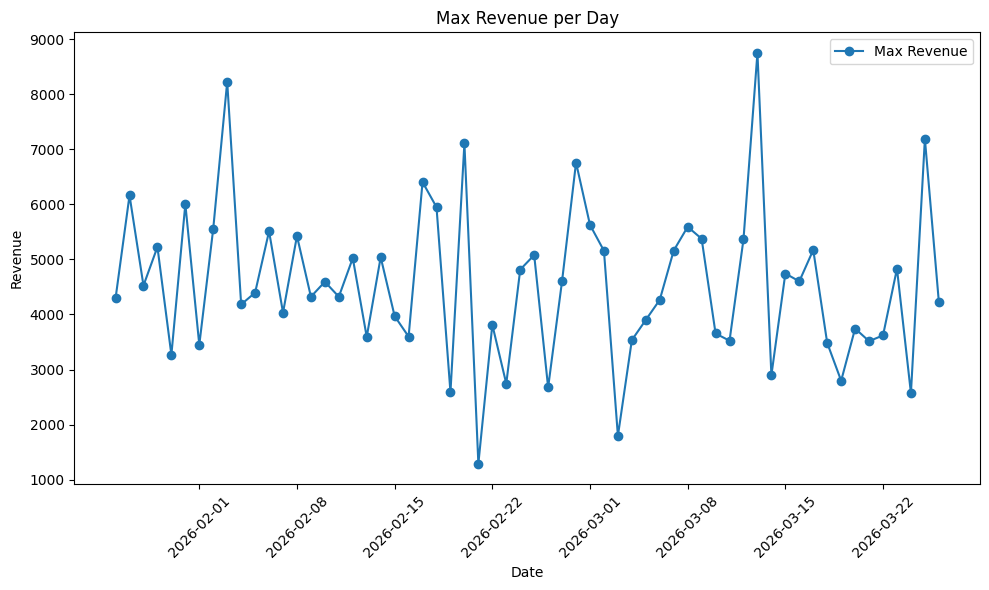

In [77]:
daily_df = pd.DataFrame({
    'order_date': df['order_date'],
    'revenue': daily_revenue
})
daily_df['order_date'] = pd.to_datetime(daily_df['order_date'])

max_per_day = daily_df.groupby('order_date', as_index=False)['revenue'].max()

plt.figure(figsize=(10,6))
plt.plot(max_per_day['order_date'], max_per_day['revenue'], marker='o')

plt.xticks(rotation=45)
plt.title("Max Revenue per Day")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend(["Max Revenue"])
plt.tight_layout()
plt.show()



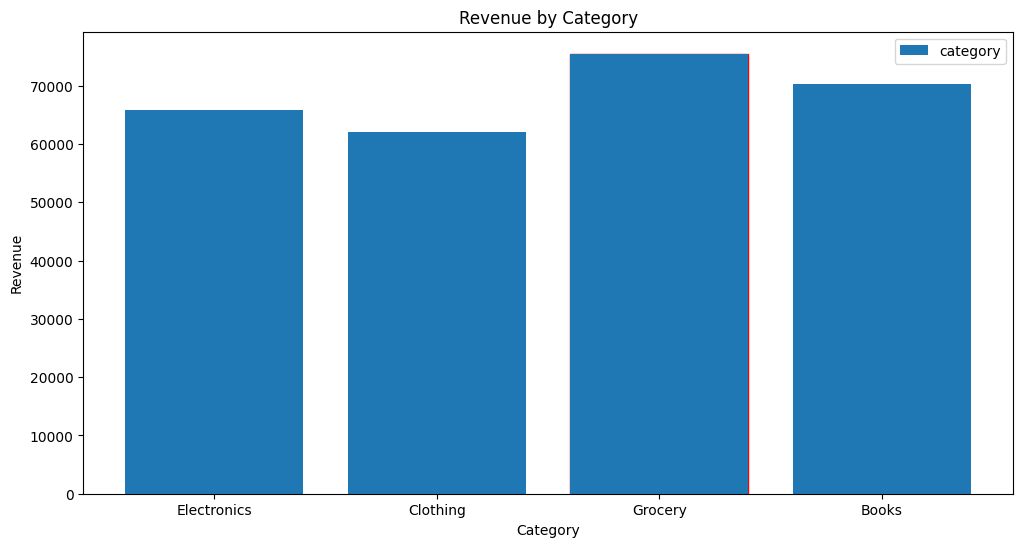

In [74]:
plt.figure(figsize=(12,6))
x = df['category']
y = revenue_category

bars = plt.bar(x, y)

max_index = x.argmax()

bars[max_index].set_color('red')

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.legend(["category", "highest"])

plt.show()